# Data

The aim of this notebook is to create a dataset of Rice assets.

In this notebook we follow the different steps:
1. Library Importation
2. Data Importation
3. Data Exploration
4. Data Cleaning
5. Data Saving

## 1. Library Importation

In [142]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np

## 2. Data Importation

**The Primary Anchor (1 asset)**: 

- rough rice futures (source: Investing.com)

**The Sector Proxies (2–4 assets): Relevant ETFs to capture broader sector beta**
- Invesco DB Agriculture Fund, DBA (yfinance)
- iPath Bloomberg Grains ETN, JJG (yfinance)
- Elements Rogers International Agriculture ETN, RJA (yfinance)
- WisdomTree Grains ETF, 1688.T (yfinance)

**The Individual Universe (10–15 assets): companies
directly involved in the commodity’s value chain**


- KRBL Limited, KRBL.NS (yfinance) – Indian company specializing in basmati rice production and export
- LT Foods Limited, LTFOODS.NS (yfinance) – Indian rice producer and owner of the Daawat basmati brand
- Chaman Lal Setia Exports Ltd, CLSEL.NS (yfinance) – Indian exporter of basmati rice
- Kohinoor Foods Ltd, KOHINOOR.NS (yfinance) – Indian basmati rice producer and exporter
- Archer Daniels Midland Company, ADM (yfinance) – Global agribusiness and grain trading company
- Bunge Global SA, BG (yfinance) – Multinational agribusiness and food company specializing in grain trading
- Olam Group Ltd, VC2.SI (yfinance) – Singapore-based agricultural commodity trader involved in rice and other crops
- Village Farms International Inc, VFF (yfinance) – Agricultural producer focused on controlled-environment farming
- Nutrien Ltd, NTR (yfinance) – Canadian agricultural input company and fertilizer producer supporting global crop production
- Mosaic Company, MOS (yfinance) – Major producer of phosphate and potash fertilizers used in agriculture
- CF Industries Holdings Inc, CF (yfinance) – Global manufacturer of nitrogen fertilizers for crop production
- Adecoagro SA, AGRO (yfinance) – Agricultural production company operating farms and food processing in South America
- Fresh Del Monte Produce Inc, FDP (yfinance) – Global agricultural company involved in food production and distribution


In [143]:
#anchor  = pd.read_csv("futures_rice.csv")
anchor = yf.download("ZR=F", start="2018-01-01", progress=False)
sector_proxies = [
    "DBA",         
    "RJA",     
    "1688.T"   
]

companies = [
    "KRBL.NS",
    "LTFOODS.NS",
    "CLSEL.NS",
    "ADM",
    "BG",
    "VC2.SI",
    "VFF",
    "NTR",
    "MOS",
    "CF",
    "AGRO",
    "FDP"
]

In [144]:
tickers = sector_proxies + companies


data = yf.download(tickers, start="2018-01-01", progress=False)

close_prices = data["Close"]

print(close_prices.head())

Ticker      1688.T        ADM      AGRO         BG         CF  CLSEL.NS  \
Date                                                                      
2018-01-01   395.0        NaN       NaN        NaN        NaN       NaN   
2018-01-02   395.0  31.407625  9.198832  52.966423  35.073055       NaN   
2018-01-03   395.0  31.164761  9.394552  54.103806  35.081184       NaN   
2018-01-04   399.0  31.689669  9.350070  54.898426  35.447029       NaN   
2018-01-05   390.0  31.478125  9.207727  54.485519  35.503941       NaN   

Ticker            DBA        FDP     KRBL.NS  LTFOODS.NS        MOS  \
Date                                                                  
2018-01-01        NaN        NaN  556.974487         NaN        NaN   
2018-01-02  16.306482  39.298069  555.493774         NaN  23.238758   
2018-01-03  16.297888  39.524147  560.167603         NaN  23.029482   
2018-01-04  16.272100  40.353153  566.276001         NaN  23.386997   
2018-01-05  16.186142  40.361534  577.104614    

In [145]:
#anchor["Date"] = pd.to_datetime(anchor["Date"], dayfirst=True)
#anchor["Dernier"] = anchor["Dernier"].str.replace(",", ".").astype(float)
#anchor = anchor.set_index("Date")

#anchor_close = anchor["Dernier"].rename("Futures")

anchor_close = anchor["Close"]

close_prices = close_prices.join(anchor_close)

df_raw = close_prices.copy()
df_raw = df_raw.rename(columns={"ZR=F": "Futures"})

## 3. Data Exploration

This step aims to give a clear overview of the raw data. This overview will be particularly useful to understand the data and prepare the cleaning part.

In [146]:
def plot_missing_proportions(
    df: pd.DataFrame,
    title: str = "Missing value proportion by asset"
) -> pd.Series:
    """
    Plot the proportion of missing values for each column in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    title : str
        Plot title.

    Returns
    -------
    pd.Series
        Missing value proportions by column.
    """
    if df.empty:
        raise ValueError("The input DataFrame is empty.")

    missing_prop = df.isna().mean().sort_values(ascending=False)

    ax = missing_prop.plot(kind="bar", figsize=(12, 6))
    ax.set_title(title)
    ax.set_xlabel("Assets")
    ax.set_ylabel("Missing value proportion")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.3)

    for i, value in enumerate(missing_prop):
        ax.text(i, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return missing_prop

def price_visualization(df: pd.DataFrame, title: str = "Asset price trends") -> None:
    # Normalize all prices to 100 at the start of the period for comparison.
    first_valid = df.apply(lambda col: col[col.notna()].iloc[0])
    df_norm = df / first_valid * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # --- Plot 1: Raw prices ---
    for col in df.columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1.2)
    axes[0].set_title('Raw Prices (2020–2026)', fontsize=13)
    axes[0].set_ylabel('Price (USD or local currency)')
    axes[0].legend(fontsize=9)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # --- Plot 2: Normalized prices (rebased to 100) ---
    for col in df_norm.columns:
        axes[1].plot(df_norm.index, df_norm[col], label=col, linewidth=1.2)
    axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title('Normalized Prices (rebased to 100 at start)', fontsize=13)
    axes[1].set_ylabel('Index (base = 100)')
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [147]:
df_raw

Ticker,1688.T,ADM,AGRO,BG,CF,CLSEL.NS,DBA,FDP,KRBL.NS,LTFOODS.NS,MOS,NTR,RJA,VC2.SI,VFF,Futures
Date,,,,,,,,,,,,,,,,
2018-01-01,395.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,556.974487,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,395.000000,31.407625,9.198832,52.966423,35.073055,NaN,16.306482,39.298069,555.493774,NaN,23.238758,41.927879,6.06,1.330321,NaN,1153.5
2018-01-03,395.000000,31.164761,9.394552,54.103806,35.081184,NaN,16.297888,39.524147,560.167603,NaN,23.029482,42.395027,6.08,1.310757,NaN,1141.0
2018-01-04,399.000000,31.689669,9.350070,54.898426,35.447029,NaN,16.272100,40.353153,566.276001,NaN,23.386997,42.540527,6.08,1.330321,NaN,1147.5
2018-01-05,390.000000,31.478125,9.207727,54.485519,35.503941,NaN,16.186142,40.361534,577.104614,NaN,23.421879,42.678375,6.04,1.330321,NaN,1156.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,590.000000,67.989998,13.190000,120.820000,120.180000,221.500000,26.840000,41.970001,285.200012,364.000000,24.080000,72.860001,NaN,0.845000,2.68,1093.5
2026-03-24,569.900024,71.440002,13.970000,124.089996,126.919998,225.850006,26.889999,42.549999,296.350006,379.049988,25.200001,76.820000,NaN,0.845000,2.81,1099.0
2026-03-25,567.500000,71.660004,14.700000,125.400002,128.110001,228.199997,26.959999,42.480000,303.100006,384.049988,26.190001,76.620003,NaN,0.845000,2.85,1097.5


In [148]:
print(f"Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} trading days, {df_raw.shape[1]} assets)")
print(f"Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print()
print("Columns (assets):")
print(list(df_raw.columns))

Dataset shape: (2153, 16)  (2153 trading days, 16 assets)
Date range: 2018-01-01 → 2026-03-27

Columns (assets):
['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'CLSEL.NS', 'DBA', 'FDP', 'KRBL.NS', 'LTFOODS.NS', 'MOS', 'NTR', 'RJA', 'VC2.SI', 'VFF', 'Futures']


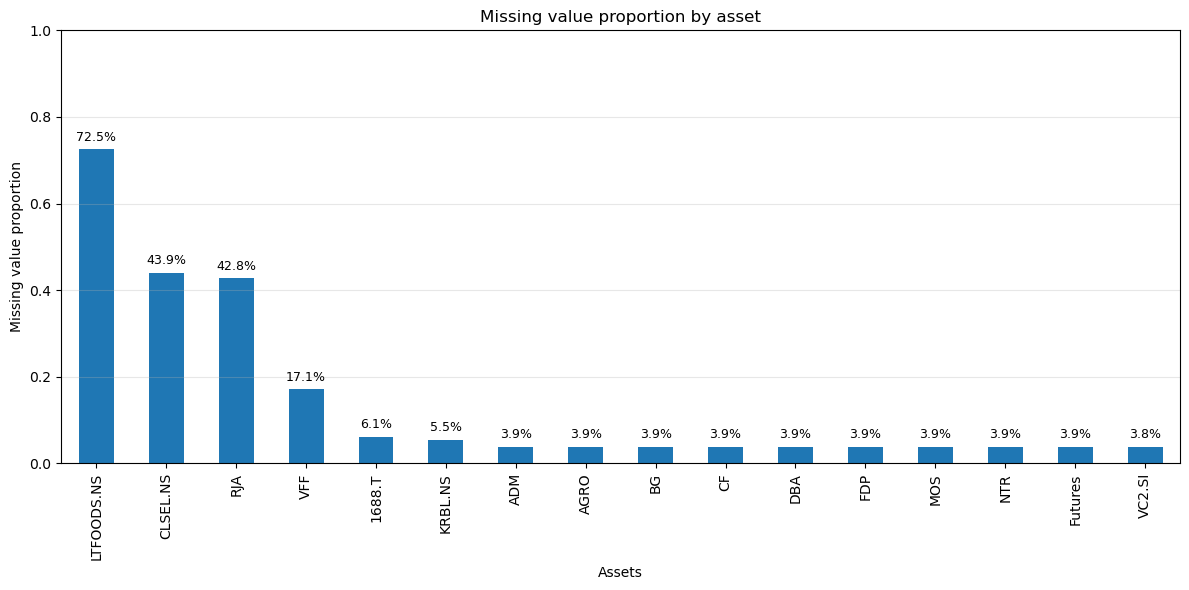

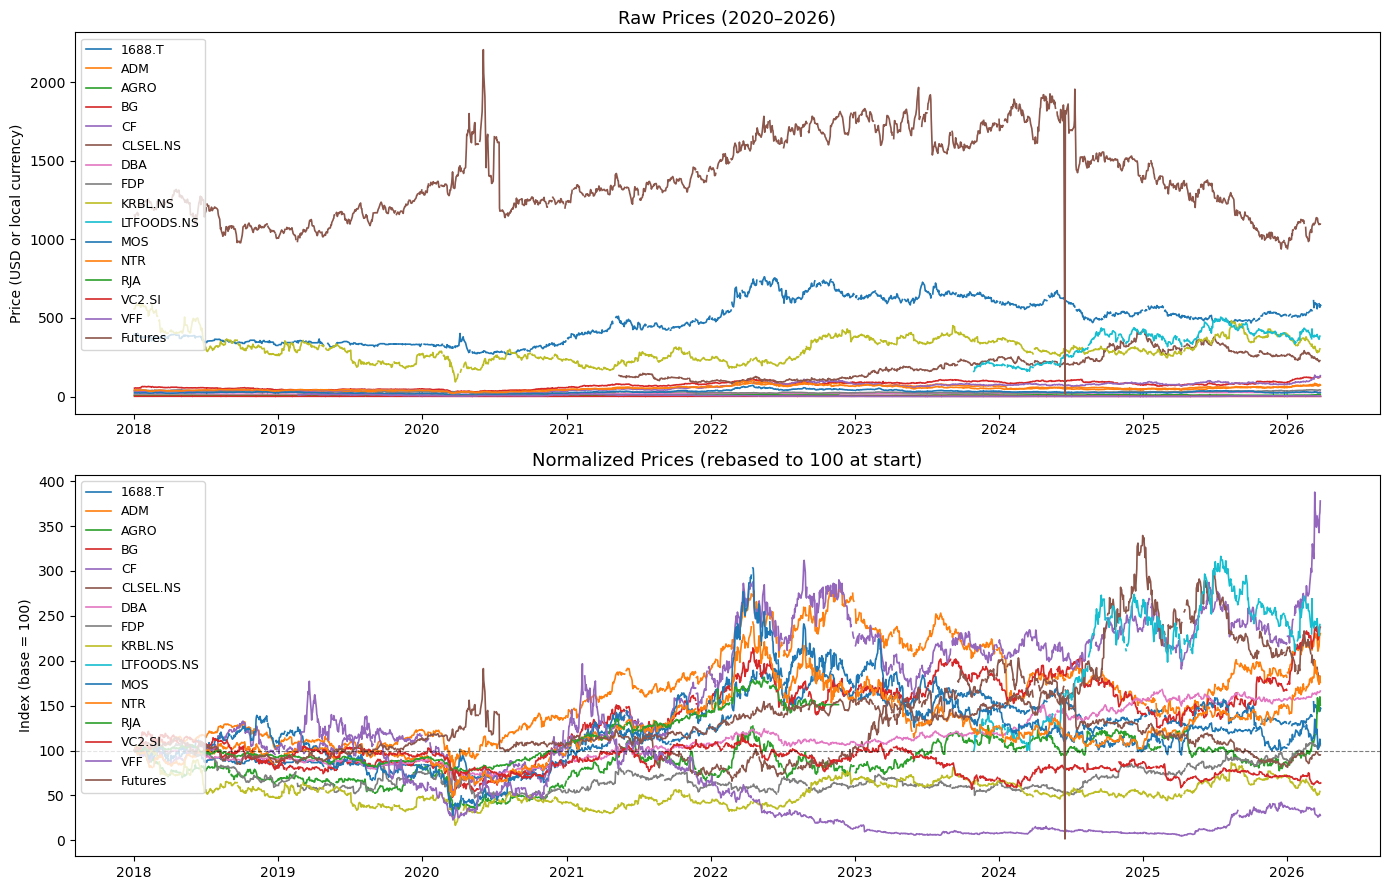

In [149]:
plot_missing_proportions(df_raw)
price_visualization(df_raw)

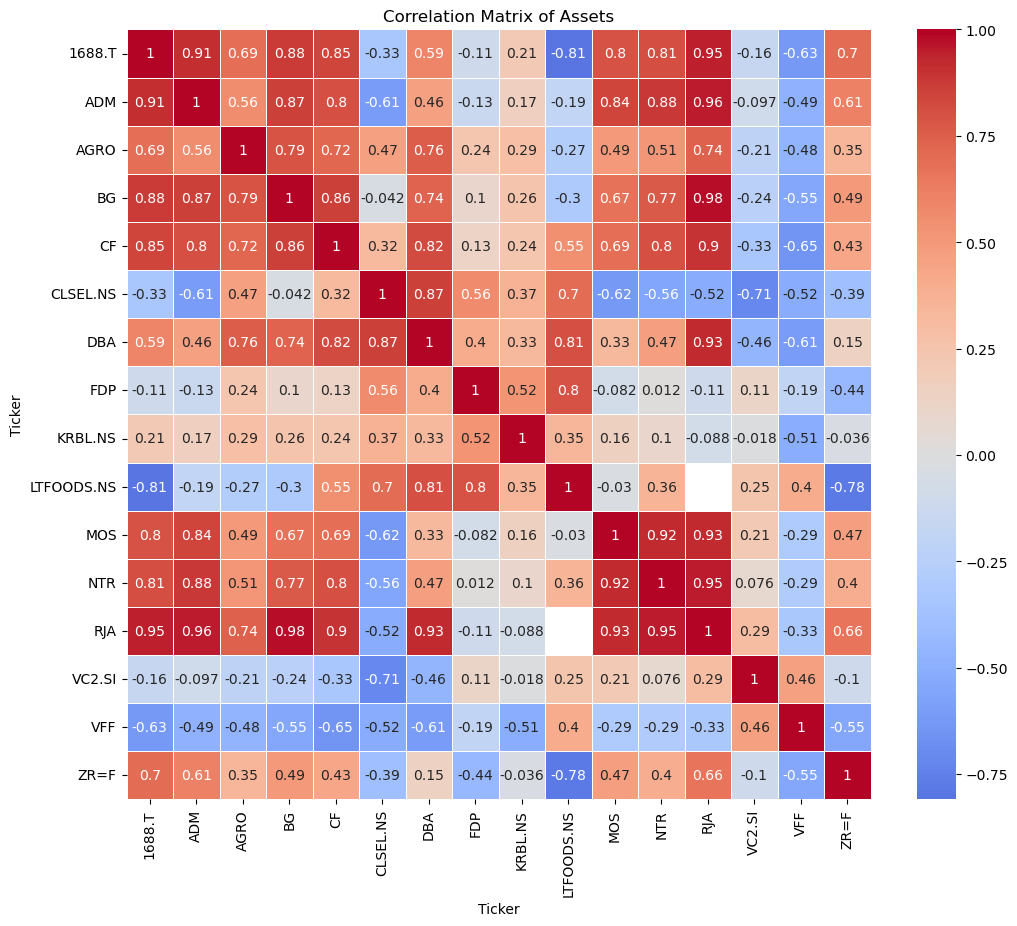

In [150]:
corr_matrix = close_prices.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Assets")
plt.show()

# 4. Data Cleaning

In [151]:
# ==========================
# GLOBAL VARIABLES
# ==========================

START = '2018-01-01'

### 4.1 Keep rows where the Futures is available

`Futures` variable contains NaN values up until 2020. Thus we will start our dataset from this date. Having values up to 2026. We still keep more than 5 years of data in our dataset. 

In [152]:
# ==========================
# DATA CLEANING
# ==========================

ANCHOR = 'Futures'
df = df_raw[df_raw[ANCHOR].notna()].copy()
df = df[df.index >= START]

print(f"After anchor filter — shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print()

After anchor filter — shape: (2070, 16)
Date range: 2018-01-02 → 2026-03-26



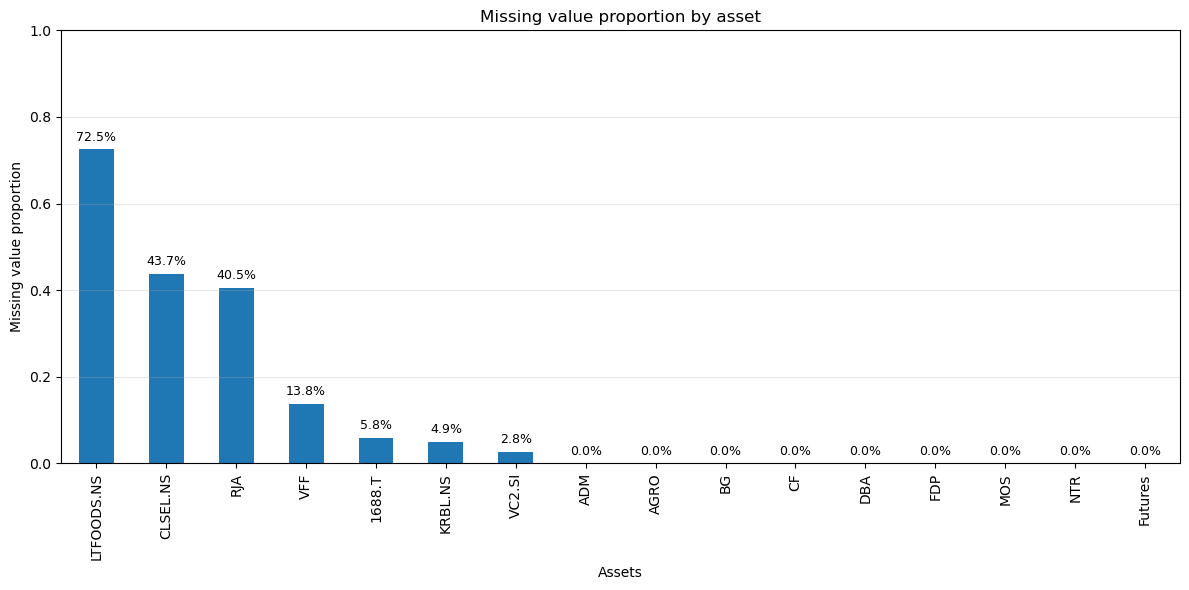

Ticker
LTFOODS.NS    0.725121
CLSEL.NS      0.437198
RJA           0.404831
VFF           0.138164
1688.T        0.058454
KRBL.NS       0.049275
VC2.SI        0.027536
ADM           0.000483
AGRO          0.000483
BG            0.000483
CF            0.000483
DBA           0.000483
FDP           0.000483
MOS           0.000483
NTR           0.000483
Futures       0.000000
dtype: float64

In [153]:
plot_missing_proportions(df)

### 4.2 Drop assets with more than 20% missing values

In [154]:
MISSING_THRESHOLD = 0.20
missing_pct = df.isnull().mean()
print("Missing value rate per asset:")
print(missing_pct.round(4).to_frame('Missing %').to_string())
print()

assets_to_keep = missing_pct[missing_pct <= MISSING_THRESHOLD].index.tolist()
assets_dropped = missing_pct[missing_pct >  MISSING_THRESHOLD].index.tolist()

print(f"Assets dropped (>{MISSING_THRESHOLD*100:.0f}% missing): {assets_dropped}")
print(f"Assets retained for screening: {assets_to_keep}")
print()

df = df[assets_to_keep].copy()

Missing value rate per asset:
            Missing %
Ticker               
1688.T         0.0585
ADM            0.0005
AGRO           0.0005
BG             0.0005
CF             0.0005
CLSEL.NS       0.4372
DBA            0.0005
FDP            0.0005
KRBL.NS        0.0493
LTFOODS.NS     0.7251
MOS            0.0005
NTR            0.0005
RJA            0.4048
VC2.SI         0.0275
VFF            0.1382
Futures        0.0000

Assets dropped (>20% missing): ['CLSEL.NS', 'LTFOODS.NS', 'RJA']
Assets retained for screening: ['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'DBA', 'FDP', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'Futures']



### 4.3 Forward-fill remaining NaNs

In [155]:
# Step 3: Forward-fill remaining NaNs (align trading days across markets)
# then drop any residual NaN rows
df = df.ffill().dropna()

# Make sure the anchor is still present
assert ANCHOR in df.columns, f"ERROR: Anchor '{ANCHOR}' was dropped — lower MISSING_THRESHOLD."

ALL_ASSETS = list(df.columns)   # full universe passed to screening

print(f"All selected assets for Section 3 screening: {ALL_ASSETS}")

All selected assets for Section 3 screening: ['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'DBA', 'FDP', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'Futures']


### 4.4 Outliers

### Why handle the outliers?

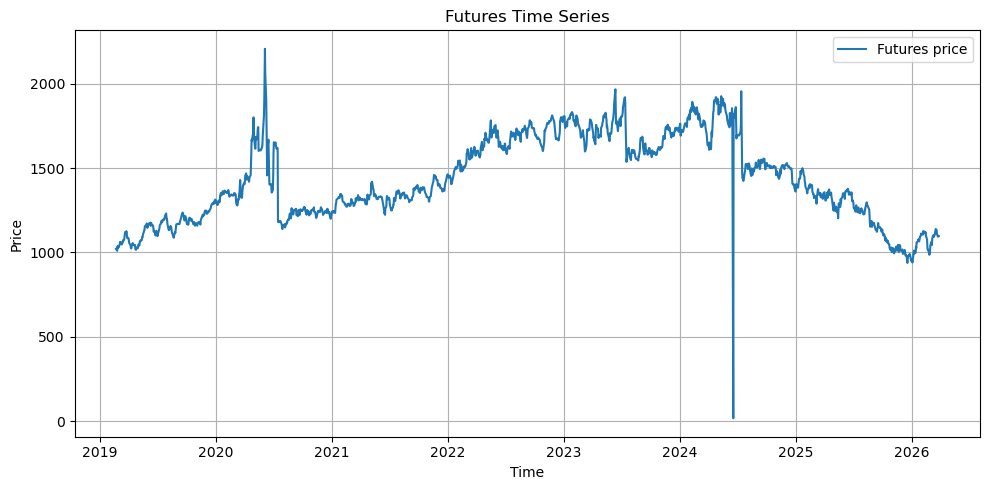

In [156]:
plt.figure(figsize=(10, 5))

plt.plot(df["Futures"], label="Futures price")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Futures Time Series")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

As we can see there are some strange prices variation, like in 2024.

In [ ]:
# 1. log returns
df["log_ret"] = np.log(df["Futures"]).diff()

# 2. threshold
threshold = 5 * df["log_ret"].std()

outliers = df["log_ret"].abs() > threshold

# 3. clip
df["log_ret_clean"] = df["log_ret"].clip(
    lower=-threshold,
    upper=threshold
)

df["log_ret_clean"].iloc[0] = 0  # évite NaN au début

# 4. reconstruction
df["Futures"] = np.exp(df["log_ret_clean"].cumsum())

# remettre niveau initial
df["Futures"] *= df["Futures"].iloc[0]

print(f"Nombre d'outliers détectés : {outliers.sum()}")

Nombre d'outliers détectés : 2


C:\Users\mathi\AppData\Local\Temp\ipykernel_36804\1450772062.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["log_ret_clean"].iloc[0] = 0  # évite NaN au début


### 4.5 Price visualization

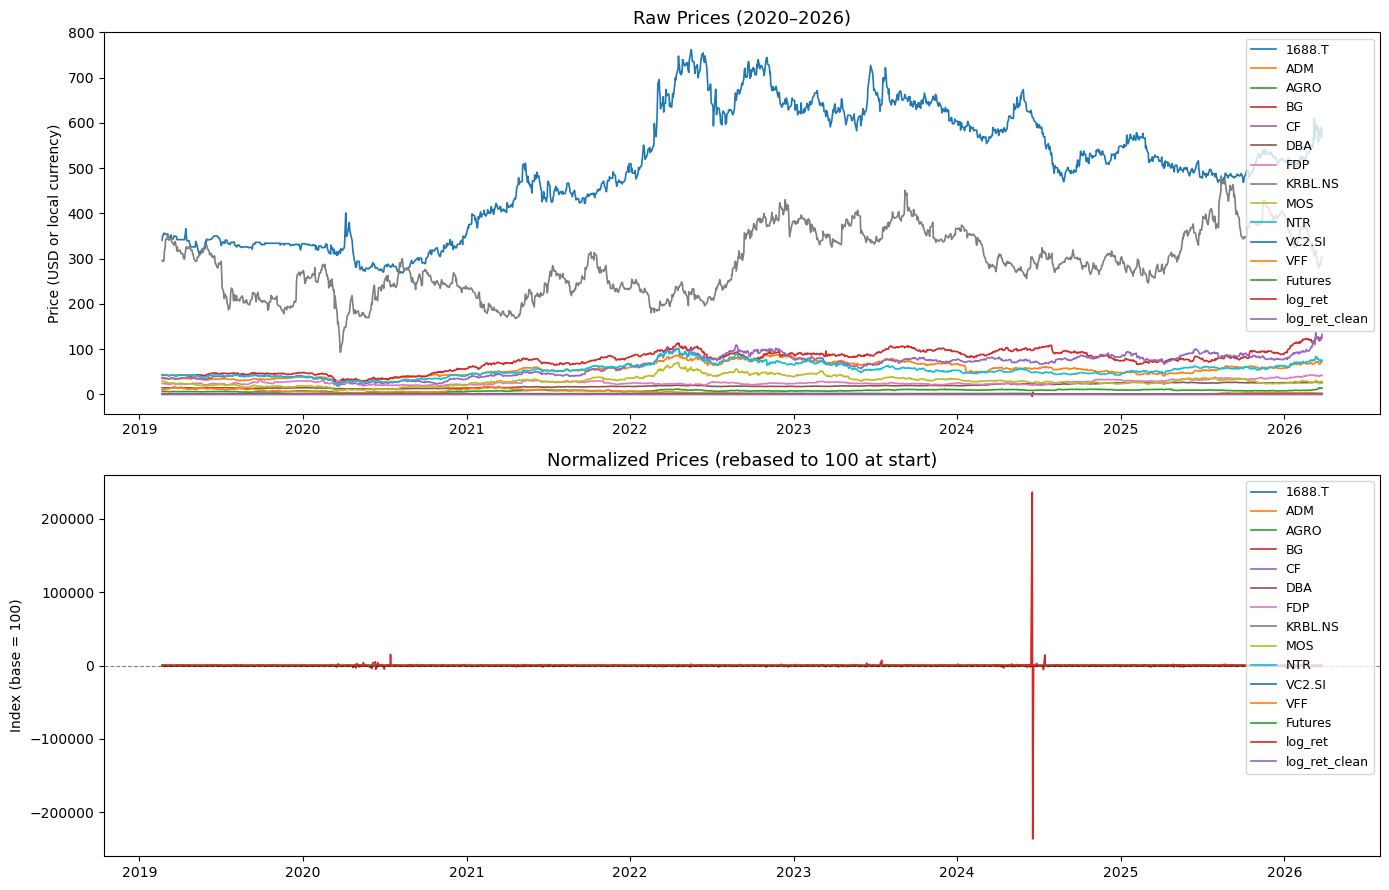

In [158]:
price_visualization(df)

# 5. Data Saving

In [159]:
df.to_csv("data.csv")